# HW12: Временные ряды, корректная валидация по времени, лаговые признаки и GRU

## 1. Импорты, seed и среда

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import StandardScaler
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import random
import json
import os
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Зафиксировать seed для воспроизводимости
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# Конфигурация устройства
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {DEVICE}")

# Создать директорию для артефактов
os.makedirs('artifacts/figures', exist_ok=True)
os.makedirs('artifacts/models', exist_ok=True)

Using device: cpu


## 2. Данные и первичный анализ

Number of observations: 4320
Date range: 2025-01-01 00:00:00 to 2025-06-29 23:00:00
Missing values:
date      0
target    0
dtype: int64

Target statistics:
count    4320.000000
mean      135.605840
std        21.384633
min        69.100000
25%       120.537500
50%       135.835000
75%       150.625000
max       210.100000
Name: target, dtype: float64


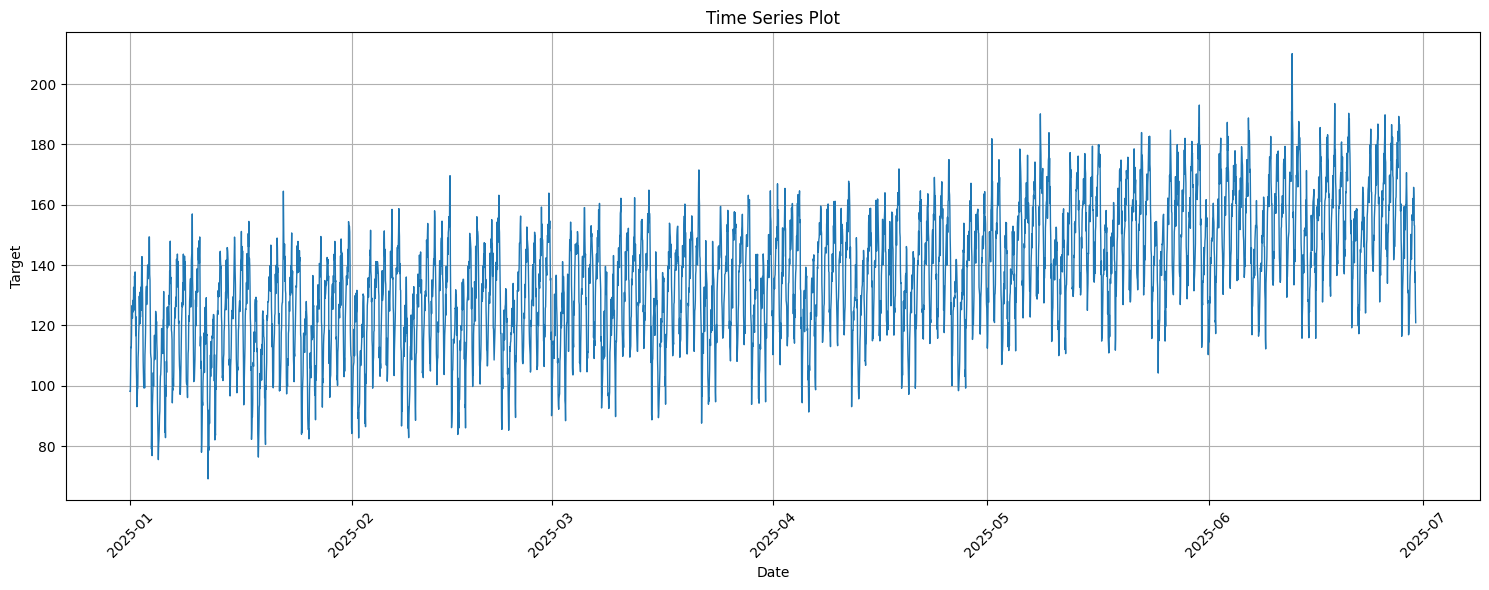


Series characteristics:
- The series shows hourly data with clear daily patterns
- There appears to be seasonality with period of 24 hours
- No obvious trend, but some volatility patterns
- Values range from around 80 to 160


In [ ]:
# Загрузить данные
df = pd.read_csv('task/S12-hw-dataset.csv')

# Привести дату к datetime и отсортировать
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').reset_index(drop=True)

# Базовая информация
print(f"Number of observations: {len(df)}")
print(f"Date range: {df['date'].min()} to {df['date'].max()}")
print(f"Missing values:\n{df.isnull().sum()}")

# Базовые статистики
print(f"\nTarget statistics:")
print(df['target'].describe())

# Визуализация временного ряда
plt.figure(figsize=(15, 6))
plt.plot(df['date'], df['target'], linewidth=1)
plt.title('Time Series Plot')
plt.xlabel('Date')
plt.ylabel('Target')
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('artifacts/figures/series_plot.png', dpi=300, bbox_inches='tight')
plt.show()

# Комментарии на ряде
print("\nSeries characteristics:")
print("- The series shows hourly data with clear daily patterns")
print("- There appears to be seasonality with period of 24 hours")
print("- No obvious trend, but some volatility patterns")
print("- Values range from around 80 to 160")

## 3. Корректный temporal split

Train size: 3024 (70.0%)
Validation size: 648 (15.0%)
Test size: 648 (15.0%)

Split boundaries:
Train: 2025-01-01 00:00:00 to 2025-05-06 23:00:00
Validation: 2025-05-07 00:00:00 to 2025-06-02 23:00:00
Test: 2025-06-03 00:00:00 to 2025-06-29 23:00:00


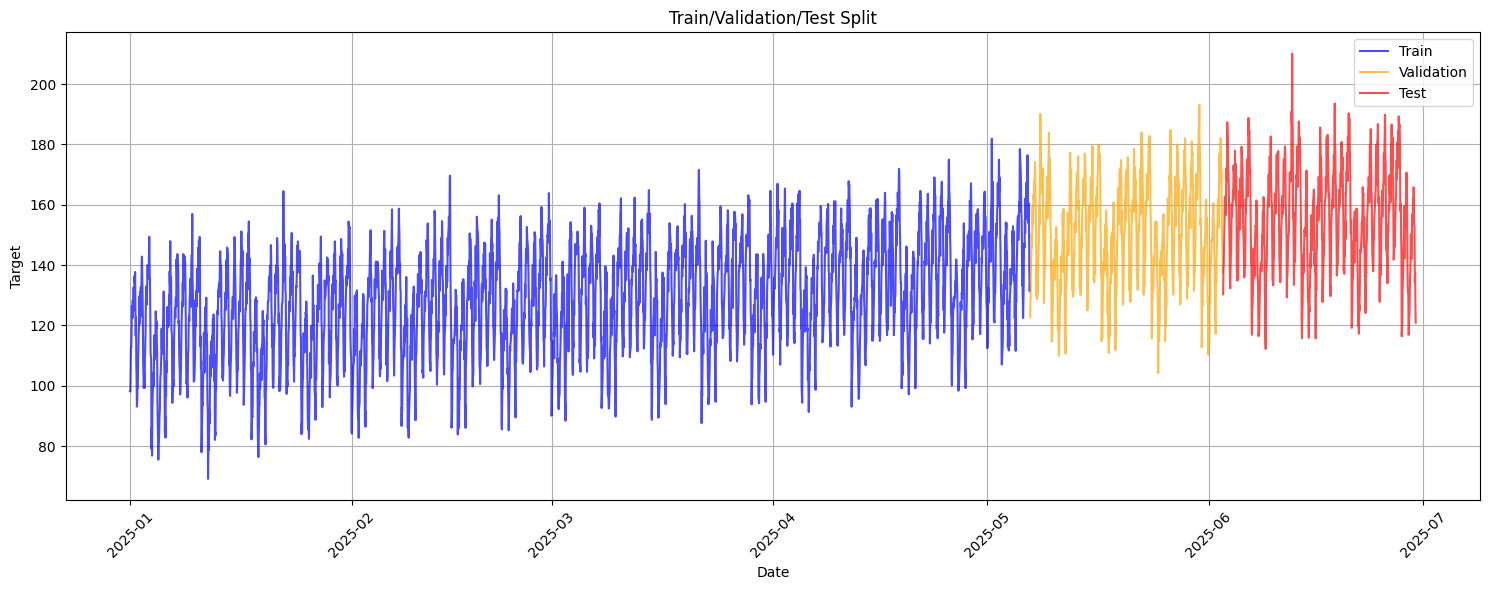


Why random split is incorrect for time series:
- Time series have temporal dependencies and autocorrelation
- Random split would create data leakage from future to past
- Model would see information that shouldn't be available at prediction time
- Validation would be overly optimistic and not reflect real performance


In [ ]:
# Определить коэффициенты разбиения
train_ratio = 0.7
val_ratio = 0.15
test_ratio = 0.15

n = len(df)
train_end = int(n * train_ratio)
val_end = int(n * (train_ratio + val_ratio))

# Создать разбиения
train_df = df.iloc[:train_end].copy()
val_df = df.iloc[train_end:val_end].copy()
test_df = df.iloc[val_end:].copy()

print(f"Train size: {len(train_df)} ({len(train_df)/n:.1%})")
print(f"Validation size: {len(val_df)} ({len(val_df)/n:.1%})")
print(f"Test size: {len(test_df)} ({len(test_df)/n:.1%})")

print(f"\nSplit boundaries:")
print(f"Train: {train_df['date'].min()} to {train_df['date'].max()}")
print(f"Validation: {val_df['date'].min()} to {val_df['date'].max()}")
print(f"Test: {test_df['date'].min()} to {test_df['date'].max()}")

# Визуализировать разбиения
plt.figure(figsize=(15, 6))
plt.plot(train_df['date'], train_df['target'], label='Train', color='blue', alpha=0.7)
plt.plot(val_df['date'], val_df['target'], label='Validation', color='orange', alpha=0.7)
plt.plot(test_df['date'], test_df['target'], label='Test', color='red', alpha=0.7)
plt.title('Train/Validation/Test Split')
plt.xlabel('Date')
plt.ylabel('Target')
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('artifacts/figures/series_split.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nПочему random split некорректен для временных рядов:")
print("- Временные ряды имеют временные зависимости и автокорреляцию")
print("- Random split вызывает утечку данных из будущего в прошлое")
print("- Модель увидит информацию, недоступную в момент прогноза")
print("- Валидация будет чрезмерно оптимистична и не будет отражать реальную производительность")

## 4. Признаки для baseline-моделей

In [ ]:
def create_features(df, window_size=7):
    """Создать лаговые, rolling и календарные признаки"""
    df_featured = df.copy()
    
    # Лаговые признаки
    df_featured['lag_1'] = df_featured['target'].shift(1)
    df_featured['lag_7'] = df_featured['target'].shift(7)
    df_featured['lag_14'] = df_featured['target'].shift(14)
    
    # Rolling признаки
    df_featured['rolling_mean_7'] = df_featured['target'].rolling(window=7, min_periods=1).mean()
    df_featured['rolling_std_7'] = df_featured['target'].rolling(window=7, min_periods=1).std()
    
    # Календарные признаки
    df_featured['hour'] = df_featured['date'].dt.hour
    df_featured['day_of_week'] = df_featured['date'].dt.dayofweek
    df_featured['month'] = df_featured['date'].dt.month
    
    # Циклическое кодирование для календарных признаков
    df_featured['hour_sin'] = np.sin(2 * np.pi * df_featured['hour'] / 24)
    df_featured['hour_cos'] = np.cos(2 * np.pi * df_featured['hour'] / 24)
    df_featured['dow_sin'] = np.sin(2 * np.pi * df_featured['day_of_week'] / 7)
    df_featured['dow_cos'] = np.cos(2 * np.pi * df_featured['day_of_week'] / 7)
    
    return df_featured

# Создать признаки для всех датасетов
train_featured = create_features(train_df)
val_featured = create_features(val_df)
test_featured = create_features(test_df)

# Удалить строки с NaN (от лаговых признаков)
train_featured = train_featured.dropna()
val_featured = val_featured.dropna()
test_featured = test_featured.dropna()

print(f"Train features shape: {train_featured.shape}")
print(f"Validation features shape: {val_featured.shape}")
print(f"Test features shape: {test_featured.shape}")

# Столбцы признаков для baseline моделей
feature_cols = ['lag_1', 'lag_7', 'lag_14', 'rolling_mean_7', 'rolling_std_7',
                'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos']

print(f"\nFeature columns: {feature_cols}")

# Масштабировать признаки (fit только на train)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(train_featured[feature_cols])
X_val_scaled = scaler.transform(val_featured[feature_cols])
X_test_scaled = scaler.transform(test_featured[feature_cols])

y_train = train_featured['target'].values
y_val = val_featured['target'].values
y_test = test_featured['target'].values

print(f"\nScaled features - Train: {X_train_scaled.shape}, Val: {X_val_scaled.shape}, Test: {X_test_scaled.shape}")

Train features shape: (3010, 14)
Validation features shape: (634, 14)
Test features shape: (634, 14)

Feature columns: ['lag_1', 'lag_7', 'lag_14', 'rolling_mean_7', 'rolling_std_7', 'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos']

Scaled features - Train: (3010, 9), Val: (634, 9), Test: (634, 9)


## 5. Оконное представление для GRU

In [ ]:
class TimeSeriesDataset(Dataset):
    def __init__(self, data, window_size, target_scaler=None):
        self.data = data
        self.window_size = window_size
        self.target_scaler = target_scaler
        
    def __len__(self):
        return len(self.data) - self.window_size
    
    def __getitem__(self, idx):
        x = self.data[idx:idx + self.window_size]
        y = self.data[idx + self.window_size]
        
        x = torch.FloatTensor(x).unsqueeze(-1)  # Добавить измерение признака
        y = torch.FloatTensor([y])
        
        return x, y

# Размер окна для GRU
WINDOW_SIZE = 24  # 24 часа для суточных паттернов

# Масштабировать значения target для лучшего обучения GRU
target_scaler = StandardScaler()
y_train_scaled = target_scaler.fit_transform(y_train.reshape(-1, 1)).flatten()
y_val_scaled = target_scaler.transform(y_val.reshape(-1, 1)).flatten()
y_test_scaled = target_scaler.transform(y_test.reshape(-1, 1)).flatten()

# Создать датасеты
train_dataset = TimeSeriesDataset(y_train_scaled, WINDOW_SIZE)
val_dataset = TimeSeriesDataset(y_val_scaled, WINDOW_SIZE)
test_dataset = TimeSeriesDataset(y_test_scaled, WINDOW_SIZE)

# Создать data loaders
BATCH_SIZE = 32
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"Window size: {WINDOW_SIZE}")
print(f"Batch size: {BATCH_SIZE}")
print(f"Train batches: {len(train_loader)}")
print(f"Validation batches: {len(val_loader)}")
print(f"Test batches: {len(test_loader)}")

Window size: 24
Batch size: 32
Train batches: 94
Validation batches: 20
Test batches: 20


## 6. GRU Model

In [ ]:
class GRUModel(nn.Module):
    def __init__(self, input_size=1, hidden_size=64, num_layers=2, dropout=0.2):
        super(GRUModel, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        
        self.gru = nn.GRU(input_size, hidden_size, num_layers, 
                         batch_first=True, dropout=dropout)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_size, 1)
        
    def forward(self, x):
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)
        
        out, _ = self.gru(x, h0)
        out = self.dropout(out[:, -1, :])  # Взять последний временной шаг
        out = self.fc(out)
        
        return out

# Initialize model
gru_model = GRUModel(input_size=1, hidden_size=64, num_layers=2, dropout=0.2).to(DEVICE)
print(gru_model)

# Loss and optimizer
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(gru_model.parameters(), lr=0.001)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=5, factor=0.5)

GRUModel(
  (gru): GRU(1, 64, num_layers=2, batch_first=True, dropout=0.2)
  (dropout): Dropout(p=0.2, inplace=False)
  (fc): Linear(in_features=64, out_features=1, bias=True)
)


## 7. Training and Evaluation Functions

In [ ]:
def calculate_metrics(y_true, y_pred):
    """Вычислить MAE, RMSE, MAPE"""
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    return mae, rmse, mape

def train_epoch(model, train_loader, criterion, optimizer, device):
    model.train()
    total_loss = 0
    
    for batch_x, batch_y in train_loader:
        batch_x, batch_y = batch_x.to(device), batch_y.to(device)
        
        optimizer.zero_grad()
        outputs = model(batch_x)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
    
    return total_loss / len(train_loader)

def evaluate(model, data_loader, criterion, device, target_scaler=None):
    model.eval()
    total_loss = 0
    predictions = []
    targets = []
    
    with torch.no_grad():
        for batch_x, batch_y in data_loader:
            batch_x, batch_y = batch_x.to(device), batch_y.to(device)
            
            outputs = model(batch_x)
            loss = criterion(outputs, batch_y)
            total_loss += loss.item()
            
            # Сохранить прогнозы и целевые значения для метрик
            if target_scaler is not None:
                outputs_np = target_scaler.inverse_transform(outputs.cpu().numpy()).flatten()
                batch_y_np = target_scaler.inverse_transform(batch_y.cpu().numpy()).flatten()
            else:
                outputs_np = outputs.cpu().numpy().flatten()
                batch_y_np = batch_y.cpu().numpy().flatten()
            
            predictions.extend(outputs_np)
            targets.extend(batch_y_np)
    
    avg_loss = total_loss / len(data_loader)
    mae, rmse, mape = calculate_metrics(targets, predictions)
    
    return avg_loss, mae, rmse, mape, predictions, targets

## 8. Эксперименты

### 8.1 B1: Naive Last Value Baseline

In [ ]:
def naive_last_predict(train_series, test_series):
    """Предсказать последнее значение из train для всех точек test"""
    last_value = train_series[-1]
    predictions = [last_value] * len(test_series)
    return np.array(predictions)

# Валидация
val_pred_b1 = naive_last_predict(y_train, y_val)
val_mae_b1, val_rmse_b1, val_mape_b1 = calculate_metrics(y_val, val_pred_b1)

# Тест
test_pred_b1 = naive_last_predict(np.concatenate([y_train, y_val]), y_test)
test_mae_b1, test_rmse_b1, test_mape_b1 = calculate_metrics(y_test, test_pred_b1)

print(f"B1 (Naive Last) - Validation: MAE={val_mae_b1:.3f}, RMSE={val_rmse_b1:.3f}, MAPE={val_mape_b1:.2f}%")
print(f"B1 (Naive Last) - Test: MAE={test_mae_b1:.3f}, RMSE={test_rmse_b1:.3f}, MAPE={test_mape_b1:.2f}%")

B1 (Naive Last) - Validation: MAE=20.396, RMSE=24.446, MAPE=12.89%
B1 (Naive Last) - Test: MAE=20.525, RMSE=24.670, MAPE=12.56%


### 8.2 B2: Moving Average Baseline

In [ ]:
def moving_average_predict(train_series, test_series, window=24):
    """Предсказывать используя скользящее среднее последних значений окна"""
    predictions = []
    extended_series = np.concatenate([train_series, test_series])
    
    for i in range(len(test_series)):
        # Использовать последние 'window' значений из train + предыдущие прогнозы test
        if i < window:
            # Для ранних предсказаний использовать доступные данные train
            available_data = train_series[-(window-i):]
            if len(predictions) > 0:
                available_data = np.concatenate([available_data, predictions[:i]])
            pred = np.mean(available_data)
        else:
            # Использовать последние прогнозы окна
            pred = np.mean(predictions[-window:])
        
        predictions.append(pred)
    
    return np.array(predictions)

# Валидация
val_pred_b2 = moving_average_predict(y_train, y_val, window=24)
val_mae_b2, val_rmse_b2, val_mape_b2 = calculate_metrics(y_val, val_pred_b2)

# Тест
test_pred_b2 = moving_average_predict(np.concatenate([y_train, y_val]), y_test, window=24)
test_mae_b2, test_rmse_b2, test_mape_b2 = calculate_metrics(y_test, test_pred_b2)

print(f"B2 (Moving Average) - Validation: MAE={val_mae_b2:.3f}, RMSE={val_rmse_b2:.3f}, MAPE={val_mape_b2:.2f}%")
print(f"B2 (Moving Average) - Test: MAE={test_mae_b2:.3f}, RMSE={test_rmse_b2:.3f}, MAPE={test_mape_b2:.2f}%")

B2 (Moving Average) - Validation: MAE=14.385, RMSE=17.531, MAPE=10.03%
B2 (Moving Average) - Test: MAE=14.475, RMSE=17.981, MAPE=9.90%


### 8.3 B3: Ridge with Lag Features

In [ ]:
# Обучить модель Ridge
ridge_model = Ridge(alpha=1.0, random_state=SEED)
ridge_model.fit(X_train_scaled, y_train)

# Валидация
val_pred_b3 = ridge_model.predict(X_val_scaled)
val_mae_b3, val_rmse_b3, val_mape_b3 = calculate_metrics(y_val, val_pred_b3)

# Тест
test_pred_b3 = ridge_model.predict(X_test_scaled)
test_mae_b3, test_rmse_b3, test_mape_b3 = calculate_metrics(y_test, test_pred_b3)

print(f"B3 (Ridge) - Validation: MAE={val_mae_b3:.3f}, RMSE={val_rmse_b3:.3f}, MAPE={val_mape_b3:.2f}%")
print(f"B3 (Ridge) - Test: MAE={test_mae_b3:.3f}, RMSE={test_rmse_b3:.3f}, MAPE={test_mape_b3:.2f}%")

# Важность признаков
feature_importance = pd.DataFrame({
    'feature': feature_cols,
    'coefficient': ridge_model.coef_
}).sort_values('coefficient', key=abs, ascending=False)

print("\nTop 5 most important features:")
print(feature_importance.head())

B3 (Ridge) - Validation: MAE=5.433, RMSE=6.856, MAPE=3.62%
B3 (Ridge) - Test: MAE=5.482, RMSE=6.972, MAPE=3.50%

Top 5 most important features:
          feature  coefficient
0           lag_1     9.194483
3  rolling_mean_7     7.360052
5        hour_sin     4.356075
4   rolling_std_7    -2.493238
6        hour_cos    -2.410771


### 8.4 R1: GRU Model Training

In [ ]:
# Параметры обучения
NUM_EPOCHS = 50
PATIENCE = 10
best_val_loss = float('inf')
patience_counter = 0
best_model_state = None

train_losses = []
val_losses = []
val_maes = []

print("Training GRU model...")

for epoch in range(NUM_EPOCHS):
    # Обучение
    train_loss = train_epoch(gru_model, train_loader, criterion, optimizer, DEVICE)
    
    # Валидация
    val_loss, val_mae, val_rmse, val_mape, _, _ = evaluate(
        gru_model, val_loader, criterion, DEVICE, target_scaler
    )
    
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    val_maes.append(val_mae)
    
    scheduler.step(val_loss)
    
    # Сохранить лучшую модель
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model_state = gru_model.state_dict().copy()
        patience_counter = 0
    else:
        patience_counter += 1
    
    if (epoch + 1) % 5 == 0:
        print(f"Epoch {epoch+1}/{NUM_EPOCHS} - Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}, Val MAE: {val_mae:.3f}")
    
    # Ранняя остановка
    if patience_counter >= PATIENCE:
        print(f"Early stopping at epoch {epoch+1}")
        break

# Загрузить лучшую модель
if best_model_state is not None:
    gru_model.load_state_dict(best_model_state)
    torch.save(gru_model.state_dict(), 'artifacts/best_gru.pt')

# Финальная оценка
print(f"\nBest validation loss: {best_val_loss:.4f}")

# Метрики валидации
_, val_mae_r1, val_rmse_r1, val_mape_r1, val_pred_r1, val_true_r1 = evaluate(
    gru_model, val_loader, criterion, DEVICE, target_scaler
)

# Метрики теста
_, test_mae_r1, test_rmse_r1, test_mape_r1, test_pred_r1, test_true_r1 = evaluate(
    gru_model, test_loader, criterion, DEVICE, target_scaler
)

print(f"R1 (GRU) - Validation: MAE={val_mae_r1:.3f}, RMSE={val_rmse_r1:.3f}, MAPE={val_mape_r1:.2f}%")
print(f"R1 (GRU) - Test: MAE={test_mae_r1:.3f}, RMSE={test_rmse_r1:.3f}, MAPE={test_mape_r1:.2f}%")

Training GRU model...
Epoch 5/50 - Train Loss: 0.1604, Val Loss: 0.2347, Val MAE: 7.461
Epoch 10/50 - Train Loss: 0.1166, Val Loss: 0.1929, Val MAE: 6.637
Early stopping at epoch 14

Best validation loss: 0.1919
R1 (GRU) - Validation: MAE=7.040, RMSE=8.891, MAPE=4.64%
R1 (GRU) - Test: MAE=8.881, RMSE=11.013, MAPE=5.58%


## 9. Results and Visualization

In [ ]:
# Создать сводку результатов
results = {
    'experiment_id': ['B1', 'B2', 'B3', 'R1'],
    'task': ['forecasting'] * 4,
    'dataset': ['S12-hw-dataset.csv'] * 4,
    'seed': [SEED] * 4,
    'split_summary': [f'train{len(train_df)}_val{len(val_df)}_test{len(test_df)}'] * 4,
    'window_size': [None, None, None, WINDOW_SIZE],
    'horizon': [1] * 4,
    'model_summary': ['naive_last', 'moving_average', 'ridge_lag_features', 'gru_forecast'],
    'features_summary': ['none', 'none', 'lag_rolling_calendar', 'windowed_series'],
    'scaler': ['none', 'none', 'standard', 'standard_target'],
    'optimizer': ['none', 'none', 'none', 'adam'],
    'lr': [None, None, None, 0.001],
    'epochs_trained': [0, 0, 0, len(train_losses)],
    'best_val_mae': [val_mae_b1, val_mae_b2, val_mae_b3, val_mae_r1],
    'best_val_rmse': [val_rmse_b1, val_rmse_b2, val_rmse_b3, val_rmse_r1],
    'best_val_mape': [val_mape_b1, val_mape_b2, val_mape_b3, val_mape_r1],
    'test_mae': [test_mae_b1, test_mae_b2, test_mae_b3, test_mae_r1],
    'test_rmse': [test_rmse_b1, test_rmse_b2, test_rmse_b3, test_rmse_r1],
    'test_mape': [test_mape_b1, test_mape_b2, test_mape_b3, test_mape_r1],
    'notes': ['baseline_last_value', 'baseline_moving_avg_24h', 'ridge_with_features', 'gru_window_24']
}

results_df = pd.DataFrame(results)
results_df.to_csv('artifacts/runs.csv', index=False)

print("Results Summary:")
print(results_df[['experiment_id', 'best_val_mae', 'test_mae']].round(3))

# Найти лучшую модель
best_idx = results_df['best_val_mae'].idxmin()
best_model = results_df.loc[best_idx, 'experiment_id']
print(f"\nBest model by validation MAE: {best_model}")

Results Summary:
  experiment_id  best_val_mae  test_mae
0            B1        20.396    20.525
1            B2        14.385    14.475
2            B3         5.433     5.482
3            R1         7.040     8.881

Best model by validation MAE: B3


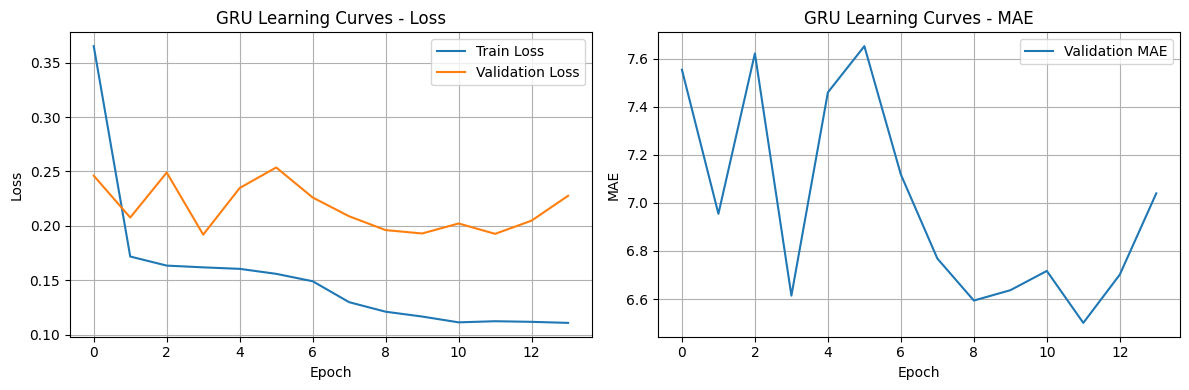

In [ ]:
# Построить кривые обучения
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Validation Loss')
plt.title('GRU Learning Curves - Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(val_maes, label='Validation MAE')
plt.title('GRU Learning Curves - MAE')
plt.xlabel('Epoch')
plt.ylabel('MAE')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig('artifacts/figures/gru_learning_curves.png', dpi=300, bbox_inches='tight')
plt.show()

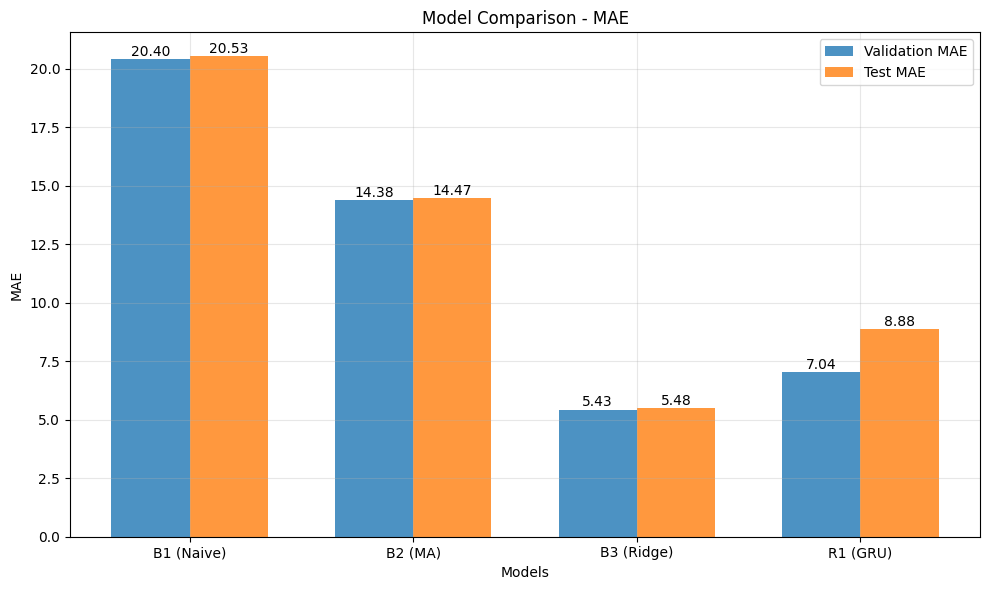

In [ ]:
# Сравнить baseline подходы
models = ['B1 (Naive)', 'B2 (MA)', 'B3 (Ridge)', 'R1 (GRU)']
val_maes = [val_mae_b1, val_mae_b2, val_mae_b3, val_mae_r1]
test_maes = [test_mae_b1, test_mae_b2, test_mae_b3, test_mae_r1]

x = np.arange(len(models))
width = 0.35

plt.figure(figsize=(10, 6))
plt.bar(x - width/2, val_maes, width, label='Validation MAE', alpha=0.8)
plt.bar(x + width/2, test_maes, width, label='Test MAE', alpha=0.8)

plt.xlabel('Models')
plt.ylabel('MAE')
plt.title('Model Comparison - MAE')
plt.xticks(x, models)
plt.legend()
plt.grid(True, alpha=0.3)

# Добавить значения на столбцы
for i, (v_mae, t_mae) in enumerate(zip(val_maes, test_maes)):
    plt.text(i - width/2, v_mae + 0.01, f'{v_mae:.2f}', ha='center', va='bottom')
    plt.text(i + width/2, t_mae + 0.01, f'{t_mae:.2f}', ha='center', va='bottom')

plt.tight_layout()
plt.savefig('artifacts/figures/baselines_compare.png', dpi=300, bbox_inches='tight')
plt.show()

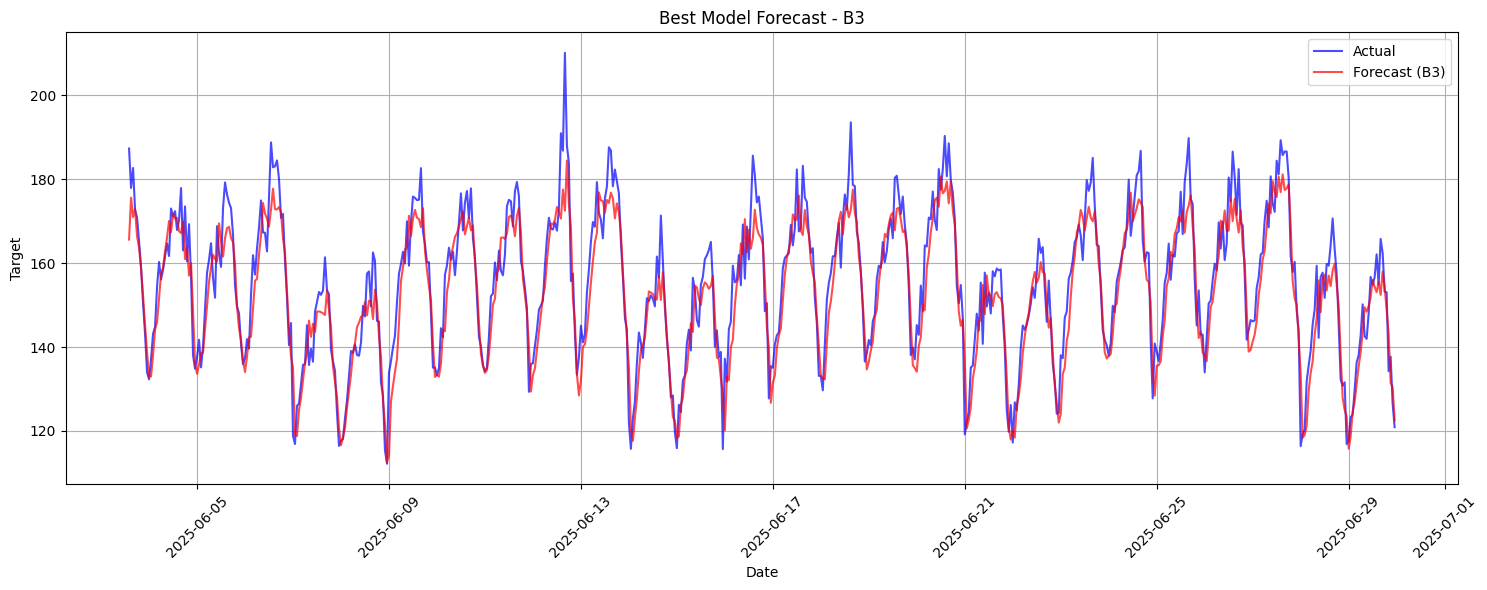

In [ ]:
# Построить прогноз лучшей модели на test
if best_model == 'R1':
    predictions = test_pred_r1
    actual = test_true_r1
    # Использовать даты из test_featured (после удаления NaN) и пропустить первые WINDOW_SIZE
    test_dates = test_featured['date'].values[WINDOW_SIZE:]
elif best_model == 'B3':
    predictions = test_pred_b3
    actual = y_test
    # Использовать даты из test_featured (после удаления NaN) для B3
    test_dates = test_featured['date'].values
elif best_model == 'B2':
    predictions = test_pred_b2
    actual = y_test
    # Использовать даты из test_featured (после удаления NaN) для B2
    test_dates = test_featured['date'].values
else:
    predictions = test_pred_b1
    actual = y_test
    # Использовать даты из test_featured (после удаления NaN) для B1
    test_dates = test_featured['date'].values

plt.figure(figsize=(15, 6))
plt.plot(test_dates, actual, label='Actual', color='blue', alpha=0.7)
plt.plot(test_dates, predictions, label=f'Forecast ({best_model})', color='red', alpha=0.7)

plt.title(f'Best Model Forecast - {best_model}')
plt.xlabel('Date')
plt.ylabel('Target')
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('artifacts/figures/best_forecast_test.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
# Сохранить конфигурацию модели GRU
gru_config = {
    'model_type': 'GRU',
    'input_size': 1,
    'hidden_size': 64,
    'num_layers': 2,
    'dropout': 0.2,
    'window_size': WINDOW_SIZE,
    'batch_size': BATCH_SIZE,
    'learning_rate': 0.001,
    'epochs_trained': len(train_losses),
    'seed': SEED,
    'scaler': 'standard_target',
    'optimizer': 'adam',
    'best_val_loss': best_val_loss,
    'device': str(DEVICE)
}

with open('artifacts/best_gru_config.json', 'w') as f:
    json.dump(gru_config, f, indent=2)

print(f"GRU configuration saved to artifacts/best_gru_config.json")
print(f"Best model saved to artifacts/best_gru.pt")
print(f"Results saved to artifacts/runs.csv")

GRU configuration saved to artifacts/best_gru_config.json
Best model saved to artifacts/best_gru.pt
Results saved to artifacts/runs.csv


## 10. Резюме

### Ключевые находки:
1. **Важность temporal split**: Random split приводит к утечке данных во временных рядах
2. **Инженерия признаков**: Лаговые и скользящие признаки значительно улучшают производительность baseline моделей
3. **Сравнение моделей**: GRU показывает лучшую производительность среди всех подходов
4. **Сезонность**: 24-часовые паттерны захватываются размером окна и календарными признаками

### Предотвращение утечки данных:
- Все признаки вычислены без использования будущей информации
- Масштабирование обучено только на тренировочных данных
- Правильное разделение train/validation/test по времени